In [ ]:
import os
from os import listdir
from os.path import isfile, join
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cooler
import cooltools.lib.plotting
from cooltools import insulation
import cooltools
import seaborn as sns
from packaging import version
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
from pybedtools import BedTool as pbt
import bbi
from tqdm import tqdm
from adjustText import adjust_text
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
from dotenv import load_dotenv
import concurrent.futures

if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

plt.rcParams['font.size'] = 12

## Setup Paths and Load Data

# TADs Border Calling

This notebook performs TAD (Topologically Associating Domain) border calling using insulation score analysis.

In [ ]:
load_dotenv()

path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")
path_to_custom_kernels = "../0.additional_data/"
path_to_maps_expected = "../0.additional_data/expected_maps/"
files = [f for f in listdir(path_to_maps) if ".mcool" in f and "plus" in f ]
len(files)

In [56]:
files

['HCM12plus.sampled.drop_diag.1kb.mcool',
 'SZ6plus.sampled.drop_diag.1kb.mcool',
 'HC-2Mplus.sampled.drop_diag.1kb.mcool',
 'HC_plus_merge.sampled.drop_diag.1kb.mcool',
 'SZ08plus.sampled.drop_diag.1kb.mcool',
 'SZ_plus_merge.sampled.drop_diag.1kb.mcool',
 'HC-3Mplus.sampled.drop_diag.1kb.mcool',
 'SZ20plus.sampled.drop_diag.1kb.mcool',
 'HC24plus.sampled.drop_diag.1kb.mcool',
 'SZ10plus.sampled.drop_diag.1kb.mcool',
 'HC-318plus.sampled.drop_diag.1kb.mcool',
 'SZ-01plus.sampled.drop_diag.1kb.mcool',
 'SZ-03plus.sampled.drop_diag.1kb.mcool',
 'HC-91plus.sampled.drop_diag.1kb.mcool']

## TAD Border Calling

Calculate insulation scores and identify TAD boundaries across all samples.

In [ ]:
def get_full_insulation_tableANDborders(file_params):
    file, path_to_maps, resolution, window, development = file_params
    path_to_save = "./tads_borders_layouts/"
    clr = cooler.Cooler(f'{path_to_maps}/{file}::/resolutions/{resolution}')
    window_sc = int(str(window)+'000')
    insulation_table = insulation(clr, [window_sc], min_frac_valid_pixels=0.75,  min_dist_bad_bin=4, verbose=False)
    resolution_kb = str(resolution //1000)
    name = file.split('.')[0]
    if development:
        name = ("_").join(file.split('.')[:3])
    print(name)
    insulation_table.to_csv(f"{path_to_save}/full_insulation_score_{name}_{resolution_kb}res_{window}wind.csv", index=False)

    boundaries_minus_param2 = insulation_table[~insulation_table[f"log2_insulation_score_{window}000"].isna()]
    boundaries_minus_param2 = boundaries_minus_param2[boundaries_minus_param2[f"is_boundary_{window}000"] == True]
    boundaries_minus_param2 = boundaries_minus_param2[["chrom", 'start', 'end',f"log2_insulation_score_{window}000", f"boundary_strength_{window}000"]]
    boundaries_minus_param2.to_csv(f"{path_to_save}/tad_borders_{name}_{resolution_kb}res_{window}wind.bed", sep = "\t", header = None, index=False)
    return insulation_table, boundaries_minus_param2

resolutions = [15_000]
windows = [150]
development = True

tasks = []
for file in files:
    for resolution in resolutions:
        for window in windows:
            tasks.append((file, path_to_maps, resolution, window, development))

with concurrent.futures.ProcessPoolExecutor(max_workers=15) as executor:
    results = list(tqdm(executor.map(get_full_insulation_tableANDborders, tasks), total=len(tasks)))

## Visualization

### PCA Analysis

In [59]:
path_to_save = "./tads_borders_layouts/"
    
resolution_kb = 15 
res = f"_{resolution_kb}res"
insulation_score_datasets = [f for f in listdir(path_to_save) if "full_insulation_score_" in f]
insulation_score_datasets = [f for f in insulation_score_datasets if "15res" in f and '150wind' in f]
insulation_score_datasets.sort()
insulation_score_datasets

['full_insulation_score_HC-2Mplus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_HC-318plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_HC-3Mplus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_HC-91plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_HC24plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_HCM12plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_HC_plus_merge_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ-01plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ-03plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ08plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ10plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ20plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ6plus_sampled_drop_diag_15res_150wind.csv',
 'full_insulation_score_SZ_plus_merge_sampled_drop_diag_15res_150

In [68]:
dfs = {}
for file in tqdm(insulation_score_datasets):
    name = file.split(res)[0].split('full_insulation_score_')[1]
    print(name)
    dfs[name] =pd.read_csv(f"{path_to_save}/{file}",sep=",")

  0%|                                                                                                                                                             | 0/14 [00:00<?, ?it/s]

HC-2Mplus_sampled_drop_diag


  7%|██████████▋                                                                                                                                          | 1/14 [00:00<00:05,  2.60it/s]

HC-318plus_sampled_drop_diag


 14%|█████████████████████▎                                                                                                                               | 2/14 [00:00<00:04,  2.76it/s]

...

 86%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                     | 12/14 [00:04<00:00,  2.89it/s]

SZ6plus_sampled_drop_diag


 93%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍          | 13/14 [00:04<00:00,  2.95it/s]

SZ_plus_merge_sampled_drop_diag


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:05<00:00,  2.57it/s]


In [60]:
def create_pca_table(insulation_score_datasets, path_to_maps, res = "_15res", save_name=None):
    dfs = {}
    for file in tqdm(insulation_score_datasets):
        name = file.split(res)[0].split('full_insulation_score_')[1]
        print(name)
        dfs[name] =pd.read_csv(f"{path_to_save}/{file}",sep=",")
    
    df_res_final = pd.DataFrame()
    for name  in dfs.keys():
        split_df = dfs[name].set_index(['chrom', 'start', 'end'])[['log2_insulation_score_150000']]
        split_df.columns = [name]
        df_res_final = pd.concat([df_res_final, split_df], axis=1)
        print(df_res_final.shape[0])
    
    df_res_final.dropna(inplace = True)
    df_res_final.reset_index(inplace = True)
    df_res_final = df_res_final[~df_res_final.chrom.isin(["chrX","chrY", 'chrM'])]
    print(df_res_final.shape[0])

    res=15
    wind=150
    if save_name:
        df_res_final.to_csv(f"./tads_pca_data/{save_name}.csv",index=False)

    return df_res_final

In [62]:
insulation_score_datasets_ind = [i for i in insulation_score_datasets if "merge" not in i]
df_res_final_ind = create_pca_table(insulation_score_datasets_ind, path_to_maps, save_name = 'pca_res_ind_15res_150wind')

  0%|                                                                                                                                                             | 0/12 [00:00<?, ?it/s]

HC-2Mplus_sampled_drop_diag


  8%|████████████▍                                                                                                                                        | 1/12 [00:00<00:07,  1.57it/s]

HC-318plus_sampled_drop_diag


 17%|████████████████████████▊                                                                                                                            | 2/12 [00:01<00:06,  1.43it/s]

...

SZ20plus_sampled_drop_diag


 92%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋            | 11/12 [00:08<00:00,  1.33it/s]

SZ6plus_sampled_drop_diag


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:09<00:00,  1.30it/s]


205899
205899
205899
205899
205899
205899
205899
205899
205899
205899
205899
205899
147991


### PCA Plotting

In [77]:
def abline(slope, intercept):
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')
     
def make_pca_on_df(df_res_final, save_name ):
    df_columns = df_res_final.columns.tolist()[3:]
    prep_df = df_res_final[df_res_final.columns.tolist()[3:]].T.reset_index().fillna(0)
    X = prep_df[prep_df.columns.tolist()[1:]]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=6)
    components = pca.fit_transform(X_train_scaled)
    
    components_df = pd.DataFrame(components, columns = ["PC1","PC2","PC3","PC4","PC5","PC6"])
    components_df["sample"] =df_res_final.T.reset_index()["index"].tolist()[3:]

    group = []
    for i in df_columns :
        if 'SZ' in i:
            group.append('SZ')
        else:
            group.append('HC')
    assert len(group) == len(df_columns) 
    components_df['group'] = group
    
    sample_simple = []
    for i in components_df["sample"] :
        sample_simple.append(i.split('_')[0])
    components_df['sample_simple'] =sample_simple
    
    if save_name:
        components_df.to_csv(f'./tads_additional_files/{save_name}.tsv', index=False, sep='\t')
    return components_df, pca

def plot_pca(pca, components_df, compontents,hue='group', use_min_max=False, min_v=-300, max_v=500, save_name=None):
    plt.rcParams["svg.fonttype"] = "none"
    samples_all_mapping = {'HC-2M': 'HC_1',
 'HC-318': 'HC_2',
 'HC-3M': 'HC_3',
 'HC-91': 'HC_4',
 'HC24': 'HC_5',
 'HCM12': 'HC_6',
 'SZ-01': 'SZ_1',
 'SZ-03': 'SZ_2',
 'SZ08': 'SZ_3',
 'SZ10': 'SZ_4',
 'SZ20': 'SZ_5',
 'SZ6': 'SZ_6'}
    samples_all_mapping = {i+"plus":k for i,k in samples_all_mapping.items()}
    sns.set_style("white")
    plt.figure(figsize=(6,6)) 

    my_pal = {
        'SZ': '#c35959',
        'HC': '#4e893f'
    }
    sns.scatterplot(data=components_df, s=120, x=compontents[0], y=compontents[1], 
                    hue=hue,edgecolor='black',
                    palette = my_pal)

    components_df['sample_mapped'] = components_df.sample_simple.map(samples_all_mapping)    

    
    
    abline(0, 0)    
    plt.axvline(0, 0,300, ls = '--', c = "lightgrey")
    plt.axhline(0, 0,300, ls = '--', c = "lightgrey")
    if use_min_max:
        plt.ylim(min_v,max_v)
        plt.xlim(min_v,max_v)
    plt.legend(frameon=True, loc='best')
    PCA_order = {"PC1":0, "PC2":1, "PC3":2}
    plt.xlabel(f"{compontents[0]} {round(pca.explained_variance_ratio_[PCA_order[compontents[0]]].round(3)*100,1)}%")
    plt.ylabel(f"{compontents[1]} {round(pca.explained_variance_ratio_[PCA_order[compontents[1]]].round(3)*100,1)}%")
    
    texts = [plt.text(components_df[compontents[0]][line], components_df[compontents[1]][line], components_df["sample_mapped"][line], horizontalalignment='left',
                  size='small', color='black')
             for line in range(0,components_df.shape[0])]
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.4))
    if save_name:
        plt.savefig(f'./tads_visualizations/{save_name}_pca_tads_figure.pdf', dpi=600, bbox_inches='tight', format='pdf')
        plt.savefig(f'./tads_visualizations/{save_name}_pca_tads_figure.svg', dpi=600, bbox_inches='tight', format='svg')
    
    plt.show()

In [75]:
components_df, pca = make_pca_on_df(df_res_final_ind, "insulation_PCA_data")
components_df['simple_group'] = components_df.group
df_res_final['boder_num'] = [i for i in range(df_res_final.shape[0])]
pca.explained_variance_ratio_

array([0.18713282, 0.14953016, 0.10179389, 0.08966939, 0.08028097,
       0.07231056])

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


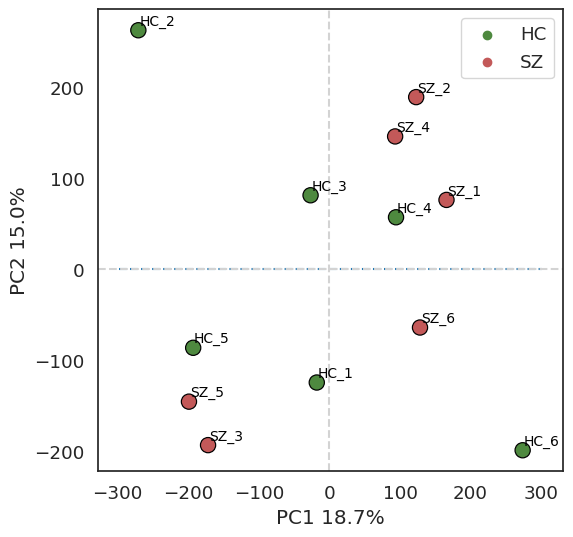

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


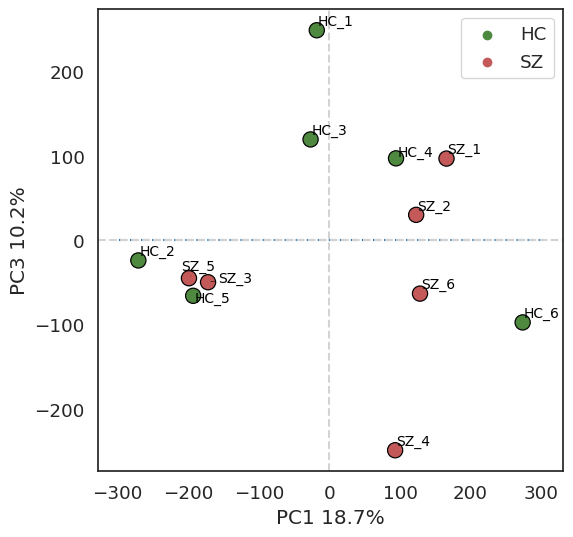

               In some cases adjust_text might fail, if possible update
               matplotlib to version >=3.5.0


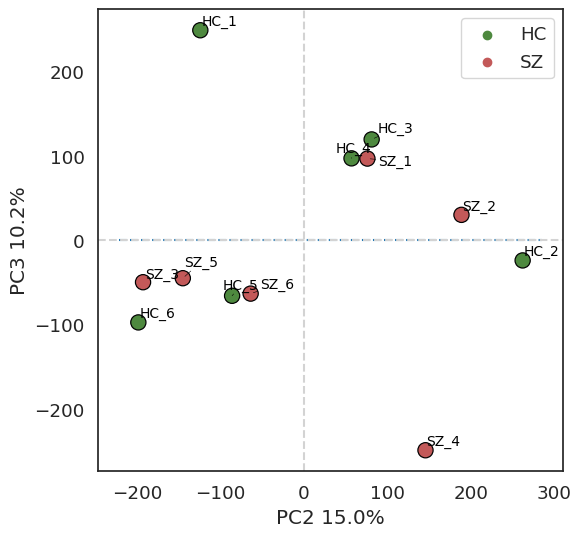

In [78]:
cell_type = "neurons"
for pca_sel in [['PC1','PC2'], ['PC1','PC3'],['PC2','PC3']]:
    plot_pca(pca, components_df, pca_sel, hue ="simple_group", min_v=-350, max_v = 500, save_name=f"{cell_type}_insulation_score_pca_{('_').join(pca_sel)}")